<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/PhaseEquilibrium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase equilibrium with NeqSim

This tutorial develops a reproducible vapour–liquid equilibrium (VLE) workflow for a
multicomponent hydrocarbon feed. It connects equilibrium theory to separator design and shows
how to validate a NeqSim flash calculation rather than treating it as a black box.

## Learning objectives

After completing the notebook, you can:

- create and flash a representative gas-condensate fluid with current NeqSim APIs;
- interpret phase fractions, phase compositions, equilibrium ratios and densities;
- verify overall and component material balances;
- check fugacity equality and the Rachford–Rice residual;
- study pressure, temperature, equation-of-state and heavy-end sensitivities; and
- translate a flash result into gas and liquid product flow rates.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )
    neqsim_version = importlib.metadata.version("neqsim")

java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {sys.version.split()[0]}")
print(f"Java runtime: {java_runtime}")

NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## Engineering context

A production separator receives one feed but delivers gas and liquid products. At fixed
temperature and pressure, a TP flash predicts whether one or more phases are stable, the
fraction of the feed in each phase, and each product composition. These results support
separator sizing, compression and stabilization studies, hydrocarbon accounting, and checks
for liquid dropout in gas systems.

This synthetic feed is representative only. It contains methane through normal octane and no
water, salts, polar chemicals, or petroleum plus fraction. Its purpose is to demonstrate a
transparent workflow without proprietary data.

## Equilibrium theory

For component $i$ at vapour–liquid equilibrium, temperature and pressure are common to both
phases and component fugacities are equal:

$$
f_i^{V} = f_i^{L}
$$

With an equation of state, fugacity is written as $f_i = x_i \phi_i P$. Therefore:

$$
y_i \phi_i^{V} P = x_i \phi_i^{L} P
$$

Here $x_i$ and $y_i$ are liquid and vapour mole fractions, $\phi_i$ is the fugacity
coefficient, and $P$ is absolute pressure. The equilibrium ratio is $K_i = y_i/x_i$.
Components with $K_i > 1$ prefer the vapour; components with $K_i < 1$ prefer the liquid.

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim import jneqsim


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 6)

COMPONENTS = {
    "methane": 0.720,
    "ethane": 0.080,
    "propane": 0.050,
    "n-butane": 0.040,
    "n-pentane": 0.035,
    "n-hexane": 0.030,
    "n-heptane": 0.025,
    "n-octane": 0.020,
}

BASE_TEMPERATURE_K = 260.0
BASE_PRESSURE_BARA = 40.0

## Assumptions, basis, and model choice

The basis is one mole of feed, so the specified component amounts are also overall mole
fractions $z_i$. Temperature is in kelvin, absolute pressure is in bara, density is in
$\mathrm{kg/m^3}$, and the separator study later uses $\mathrm{kmol/h}$.

The base model is the Soave–Redlich–Kwong (SRK) cubic equation of state with the classic
mixing rule. SRK is widely used for hydrocarbon gas-processing calculations. Multiphase
checking is enabled before the TP flash. Peng–Robinson (PR) is included later as a model
sensitivity, not as an experimental truth benchmark.

In [3]:
def build_hydrocarbon_fluid(
    composition,
    temperature_k,
    pressure_bara,
    equation_of_state="SRK",
):
    model_name = equation_of_state.upper()

    if model_name == "SRK":
        fluid = jneqsim.thermo.system.SystemSrkEos(
            temperature_k,
            pressure_bara,
        )
    elif model_name == "PR":
        fluid = jneqsim.thermo.system.SystemPrEos(
            temperature_k,
            pressure_bara,
        )
    else:
        raise ValueError(f"Unsupported equation of state: {equation_of_state}")

    for component_name, mole_fraction in composition.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


def flash_fluid(fluid):
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid

## Reproducible base case

The base case is flashed at 260 K and 40 bara. These conditions intentionally lie inside the
two-phase region for this mixture. Phase names are used when reading results, avoiding fragile
assumptions about phase index order.

In [4]:
base_fluid = build_hydrocarbon_fluid(
    composition=COMPONENTS,
    temperature_k=BASE_TEMPERATURE_K,
    pressure_bara=BASE_PRESSURE_BARA,
)
flash_fluid(base_fluid)

gas_phase = base_fluid.getPhase("gas")
oil_phase = base_fluid.getPhase("oil")

gas_fraction = float(gas_phase.getBeta())
oil_fraction = float(oil_phase.getBeta())

base_summary = pd.DataFrame(
    [
        {
            "phase": "gas",
            "mole fraction [-]": gas_fraction,
            "density [kg/m³]": float(gas_phase.getDensity("kg/m3")),
        },
        {
            "phase": "oil",
            "mole fraction [-]": oil_fraction,
            "density [kg/m³]": float(oil_phase.getDensity("kg/m3")),
        },
    ]
)

print(f"Number of phases: {base_fluid.getNumberOfPhases()}")
display(base_summary)

Number of phases: 2


,phase,mole fraction [-],density [kg/m³]
0,gas,0.72403,38.921028
1,oil,0.27597,602.500884


## Phase compositions and equilibrium ratios

The flash partitions light components toward the gas and heavy components toward the liquid.
The table reports feed composition $z_i$, liquid composition $x_i$, vapour composition $y_i$,
and $K_i$. A decreasing $K_i$ with carbon number is the expected hydrocarbon trend at these
conditions.

In [5]:
composition_rows = []

for component_name, feed_fraction in COMPONENTS.items():
    gas_component = gas_phase.getComponent(component_name)
    oil_component = oil_phase.getComponent(component_name)
    vapour_fraction = float(gas_component.getx())
    liquid_fraction = float(oil_component.getx())

    composition_rows.append(
        {
            "component": component_name,
            "z feed [-]": feed_fraction,
            "x liquid [-]": liquid_fraction,
            "y vapour [-]": vapour_fraction,
            "K = y/x [-]": vapour_fraction / liquid_fraction,
        }
    )

phase_compositions = pd.DataFrame(composition_rows)
display(phase_compositions)

,component,z feed [-],x liquid [-],y vapour [-],K = y/x [-]
0,methane,0.720,0.233253,0.905528,3.882170
1,ethane,0.080,0.114333,0.066914,0.585250
2,propane,0.050,0.128506,0.020077,0.156233
3,n-butane,0.040,0.130500,0.005505,0.042186
4,n-pentane,0.035,0.122933,0.001484,0.012068
5,n-hexane,0.030,0.107723,0.000375,0.003483
6,n-heptane,0.025,0.090341,0.000095,0.001049
7,n-octane,0.020,0.072412,0.000023,0.000315


## Material-balance validation

For vapour fraction $\beta$, each component must satisfy:

$$
z_i = (1-\beta)x_i + \beta y_i
$$

The phase mole fractions must also each sum to one. These checks detect composition extraction
errors, phase-label mistakes, and incomplete convergence.

In [6]:
phase_compositions["reconstructed z [-]"] = (
    oil_fraction * phase_compositions["x liquid [-]"]
    + gas_fraction * phase_compositions["y vapour [-]"]
)
phase_compositions["component residual [-]"] = (
    phase_compositions["reconstructed z [-]"]
    - phase_compositions["z feed [-]"]
)

maximum_component_residual = float(
    phase_compositions["component residual [-]"].abs().max()
)
gas_composition_sum = float(phase_compositions["y vapour [-]"].sum())
oil_composition_sum = float(phase_compositions["x liquid [-]"].sum())
phase_fraction_sum = gas_fraction + oil_fraction

print(f"Maximum component residual: {maximum_component_residual:.3e}")
print(f"Gas composition sum: {gas_composition_sum:.12f}")
print(f"Oil composition sum: {oil_composition_sum:.12f}")
print(f"Phase-fraction sum: {phase_fraction_sum:.12f}")

Maximum component residual: 3.331e-16
Gas composition sum: 1.000000000000
Oil composition sum: 1.000000000000
Phase-fraction sum: 1.000000000000


## Fugacity-equality validation

At equilibrium, $y_i\phi_i^V$ and $x_i\phi_i^L$ must match because both phases have the same
pressure. The normalized residual below is:

$$
r_i = \frac{y_i\phi_i^V-x_i\phi_i^L}
{\max\left(y_i\phi_i^V,\ x_i\phi_i^L\right)}
$$

A small $r_i$ confirms the equation-of-state equilibrium condition, not merely the material
balance.

In [7]:
fugacity_rows = []

for component_name in COMPONENTS:
    gas_component = gas_phase.getComponent(component_name)
    oil_component = oil_phase.getComponent(component_name)

    vapour_term = float(
        gas_component.getx() * gas_component.getFugacityCoefficient()
    )
    liquid_term = float(
        oil_component.getx() * oil_component.getFugacityCoefficient()
    )
    reference_term = max(abs(vapour_term), abs(liquid_term))
    normalized_residual = (vapour_term - liquid_term) / reference_term

    fugacity_rows.append(
        {
            "component": component_name,
            "y·φᵛ [-]": vapour_term,
            "x·φˡ [-]": liquid_term,
            "relative residual [-]": normalized_residual,
        }
    )

fugacity_check = pd.DataFrame(fugacity_rows)
maximum_fugacity_residual = float(
    fugacity_check["relative residual [-]"].abs().max()
)

display(fugacity_check)
print(f"Maximum relative fugacity residual: {maximum_fugacity_residual:.3e}")

Maximum relative fugacity residual: 8.346e-15


,component,y·φᵛ [-],x·φˡ [-],relative residual [-]
0,methane,0.811434,0.811434,8.346165e-15
1,ethane,0.045035,0.045035,3.081536e-15
2,propane,0.010703,0.010703,3.565772e-15
3,n-butane,0.002330,0.002330,3.164196e-15
4,n-pentane,0.000499,0.000499,8.256659e-15
5,n-hexane,0.000100,0.000100,3.516419e-15
6,n-heptane,0.000020,0.000020,1.169426e-15
7,n-octane,0.000004,0.000004,2.571238e-15


## Independent Rachford–Rice check

For a two-phase flash, the vapour fraction also solves:

$$
\sum_i \frac{z_i(K_i-1)}
{1+\beta(K_i-1)} = 0
$$

Evaluating this equation with the converged $K_i$ values provides a compact independent check
of the phase-fraction result.

In [8]:
rachford_rice_terms = []

for row in phase_compositions.itertuples(index=False):
    overall_fraction = getattr(row, "_1")
    equilibrium_ratio = getattr(row, "_4")
    denominator = 1.0 + gas_fraction * (equilibrium_ratio - 1.0)
    term = overall_fraction * (equilibrium_ratio - 1.0) / denominator
    rachford_rice_terms.append(term)

rachford_rice_residual = float(sum(rachford_rice_terms))

print(f"Rachford–Rice residual: {rachford_rice_residual:.3e}")

Rachford–Rice residual: -4.372e-16


## Pressure sensitivity

At fixed temperature, increasing pressure generally promotes condensation for this
gas-condensate mixture. Each point is a fresh fluid object and a new TP flash, so no mutable
state is carried between scenarios.

In [9]:
pressure_values_bara = np.arange(5.0, 105.0, 5.0)
pressure_rows = []

for pressure_bara in pressure_values_bara:
    scenario_fluid = build_hydrocarbon_fluid(
        composition=COMPONENTS,
        temperature_k=BASE_TEMPERATURE_K,
        pressure_bara=float(pressure_bara),
    )
    flash_fluid(scenario_fluid)

    scenario_gas_fraction = float(scenario_fluid.getPhase("gas").getBeta())
    pressure_rows.append(
        {
            "pressure [bara]": pressure_bara,
            "vapour fraction [-]": scenario_gas_fraction,
            "liquid fraction [-]": 1.0 - scenario_gas_fraction,
        }
    )

pressure_study = pd.DataFrame(pressure_rows)
display(pressure_study.iloc[::4].reset_index(drop=True))

,pressure [bara],vapour fraction [-],liquid fraction [-]
0,5.0,0.855953,0.144047
1,25.0,0.770291,0.229709
2,45.0,0.708760,0.291240
3,65.0,0.644409,0.355591
4,85.0,0.569956,0.430044


## Temperature sensitivity

At fixed pressure, raising temperature favours vaporization. The selected range remains
two-phase, allowing the trend to be compared without introducing discontinuities at a phase
boundary.

In [10]:
temperature_values_k = np.arange(240.0, 311.0, 5.0)
temperature_rows = []

for temperature_k in temperature_values_k:
    scenario_fluid = build_hydrocarbon_fluid(
        composition=COMPONENTS,
        temperature_k=float(temperature_k),
        pressure_bara=BASE_PRESSURE_BARA,
    )
    flash_fluid(scenario_fluid)

    scenario_gas_fraction = float(scenario_fluid.getPhase("gas").getBeta())
    temperature_rows.append(
        {
            "temperature [K]": temperature_k,
            "temperature [°C]": temperature_k - 273.15,
            "vapour fraction [-]": scenario_gas_fraction,
            "liquid fraction [-]": 1.0 - scenario_gas_fraction,
        }
    )

temperature_study = pd.DataFrame(temperature_rows)
display(temperature_study.iloc[::3].reset_index(drop=True))

,temperature [K],temperature [°C],vapour fraction [-],liquid fraction [-]
0,240.0,-33.15,0.668424,0.331576
1,255.0,-18.15,0.711683,0.288317
2,270.0,-3.15,0.746655,0.253345
3,285.0,11.85,0.776994,0.223006
4,300.0,26.85,0.804730,0.195270


## Equation-of-state sensitivity

SRK and PR use different attractive and repulsive terms. Comparing them illustrates model-form
uncertainty. Agreement does not prove accuracy; measured PVT or separator data are required for
calibration and model selection.

In [11]:
model_rows = []

for model_name in ["SRK", "PR"]:
    model_fluid = build_hydrocarbon_fluid(
        composition=COMPONENTS,
        temperature_k=BASE_TEMPERATURE_K,
        pressure_bara=BASE_PRESSURE_BARA,
        equation_of_state=model_name,
    )
    flash_fluid(model_fluid)

    model_gas = model_fluid.getPhase("gas")
    model_oil = model_fluid.getPhase("oil")
    model_rows.append(
        {
            "model": model_name,
            "vapour fraction [-]": float(model_gas.getBeta()),
            "gas density [kg/m³]": float(model_gas.getDensity("kg/m3")),
            "oil density [kg/m³]": float(model_oil.getDensity("kg/m3")),
        }
    )

model_study = pd.DataFrame(model_rows)
vapour_fraction_model_spread = float(
    model_study["vapour fraction [-]"].max()
    - model_study["vapour fraction [-]"].min()
)

display(model_study)
print(
    "SRK–PR vapour-fraction spread: "
    f"{vapour_fraction_model_spread:.5f}"
)

SRK–PR vapour-fraction spread: 0.00385


,model,vapour fraction [-],gas density [kg/m³],oil density [kg/m³]
0,SRK,0.724030,38.921028,602.500884
1,PR,0.720181,39.542785,584.466167


## Separator product accounting

For feed molar flow $F$, gas and liquid product flows are:

$$
V = \beta F
$$

$$
L = (1-\beta)F
$$

Component product flows follow from $V y_i$ and $L x_i$. This converts thermodynamic phase
equilibrium into quantities used for product recovery and downstream equipment studies.

In [12]:
feed_flow_kmol_per_h = 1000.0
gas_flow_kmol_per_h = gas_fraction * feed_flow_kmol_per_h
oil_flow_kmol_per_h = oil_fraction * feed_flow_kmol_per_h

product_table = phase_compositions[
    ["component", "z feed [-]", "x liquid [-]", "y vapour [-]"]
].copy()
product_table["feed [kmol/h]"] = (
    feed_flow_kmol_per_h * product_table["z feed [-]"]
)
product_table["gas product [kmol/h]"] = (
    gas_flow_kmol_per_h * product_table["y vapour [-]"]
)
product_table["liquid product [kmol/h]"] = (
    oil_flow_kmol_per_h * product_table["x liquid [-]"]
)
product_table["flow residual [kmol/h]"] = (
    product_table["gas product [kmol/h]"]
    + product_table["liquid product [kmol/h]"]
    - product_table["feed [kmol/h]"]
)

maximum_flow_residual = float(
    product_table["flow residual [kmol/h]"].abs().max()
)
octane_liquid_recovery = float(
    product_table.loc[
        product_table["component"] == "n-octane",
        "liquid product [kmol/h]",
    ].iloc[0]
    / product_table.loc[
        product_table["component"] == "n-octane",
        "feed [kmol/h]",
    ].iloc[0]
)

display(product_table)
print(f"Gas product: {gas_flow_kmol_per_h:.3f} kmol/h")
print(f"Liquid product: {oil_flow_kmol_per_h:.3f} kmol/h")
print(f"n-octane liquid recovery: {octane_liquid_recovery:.2%}")

Gas product: 724.030 kmol/h
Liquid product: 275.970 kmol/h
n-octane liquid recovery: 99.92%


,component,z feed [-],x liquid [-],y vapour [-],feed [kmol/h],gas product [kmol/h],liquid product [kmol/h],flow residual [kmol/h]
0,methane,0.720,0.233253,0.905528,720.0,655.629058,64.370942,2.273737e-13
1,ethane,0.080,0.114333,0.066914,80.0,48.447409,31.552591,2.842171e-14
2,propane,0.050,0.128506,0.020077,50.0,14.536239,35.463761,-7.105427e-15
3,n-butane,0.040,0.130500,0.005505,40.0,3.985928,36.014072,-7.105427e-15
4,n-pentane,0.035,0.122933,0.001484,35.0,1.074138,33.925862,-1.421085e-14
5,n-hexane,0.030,0.107723,0.000375,30.0,0.271640,29.728360,-1.065814e-14
6,n-heptane,0.025,0.090341,0.000095,25.0,0.068641,24.931359,-7.105427e-15
7,n-octane,0.020,0.072412,0.000023,20.0,0.016515,19.983485,-7.105427e-15


## Heavy-end uncertainty

Heavy-end characterization often dominates liquid-dropout uncertainty. The study transfers
successively more mole fraction from methane to normal octane while preserving a total
composition of one. It is a controlled sensitivity, not a claim that real C8+ material behaves
as pure normal octane.

In [13]:
octane_increments = np.array([0.000, 0.005, 0.010, 0.015, 0.020])
heavy_end_rows = []

for octane_increment in octane_increments:
    scenario_composition = COMPONENTS.copy()
    scenario_composition["methane"] -= float(octane_increment)
    scenario_composition["n-octane"] += float(octane_increment)

    scenario_fluid = build_hydrocarbon_fluid(
        composition=scenario_composition,
        temperature_k=BASE_TEMPERATURE_K,
        pressure_bara=BASE_PRESSURE_BARA,
    )
    flash_fluid(scenario_fluid)

    scenario_gas_fraction = float(scenario_fluid.getPhase("gas").getBeta())
    heavy_end_rows.append(
        {
            "n-octane in feed [mol%]": 100.0
            * scenario_composition["n-octane"],
            "vapour fraction [-]": scenario_gas_fraction,
            "liquid fraction [-]": 1.0 - scenario_gas_fraction,
        }
    )

heavy_end_study = pd.DataFrame(heavy_end_rows)
display(heavy_end_study)

,n-octane in feed [mol%],vapour fraction [-],liquid fraction [-]
0,2.0,0.724030,0.275970
1,2.5,0.716088,0.283912
2,3.0,0.708185,0.291815
3,3.5,0.700318,0.299682
4,4.0,0.692486,0.307514


## Visual engineering interpretation

The plots combine volatility, operating-condition, model, and characterization effects. They
use deterministic calculated values; no generated imagery or unsupported numerical data are
included.

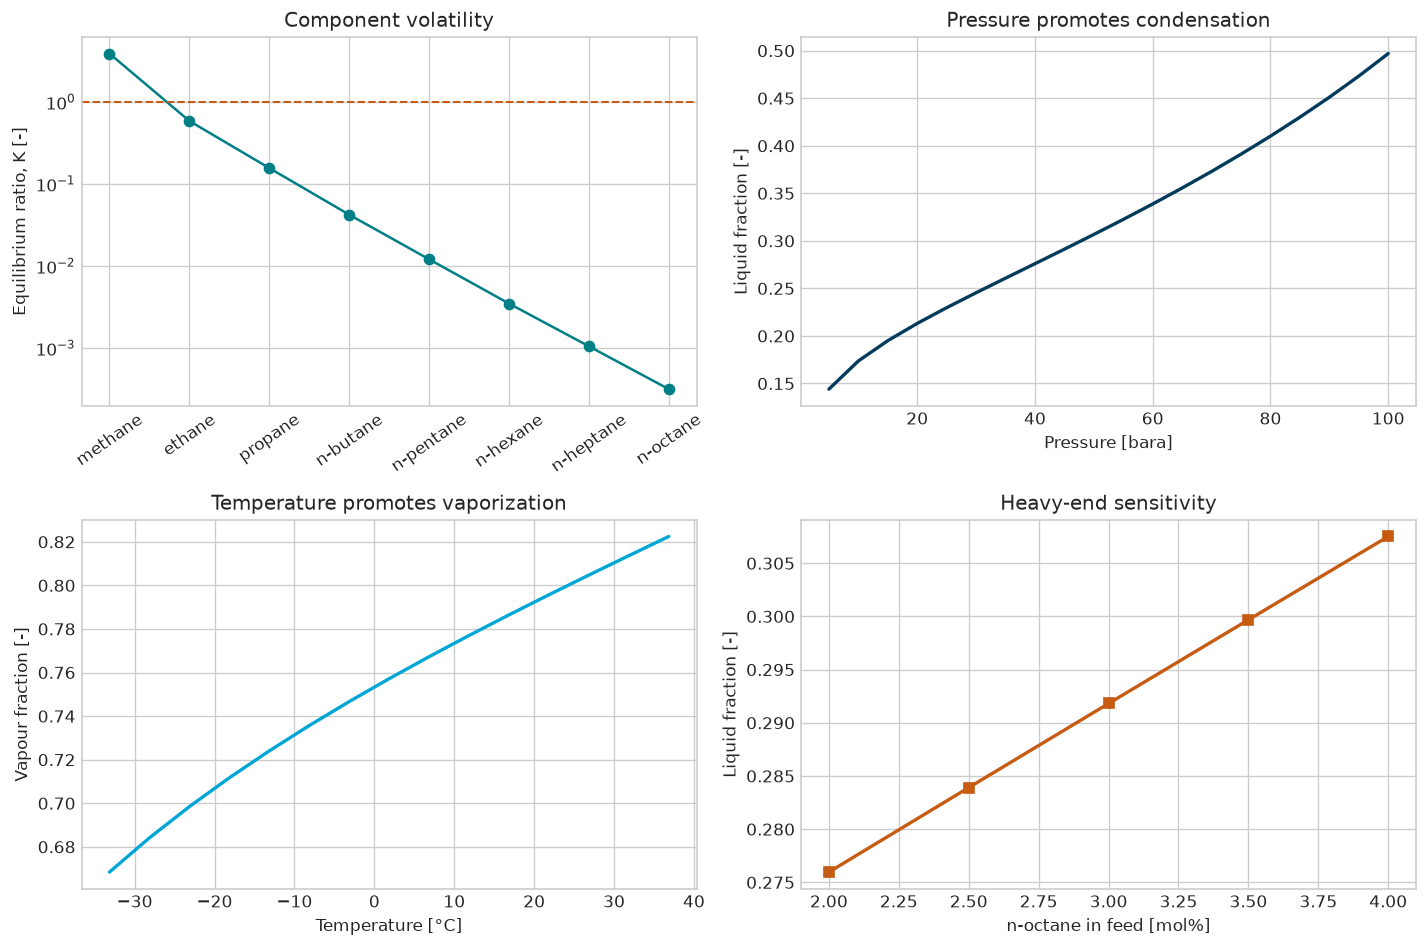

In [14]:
figure, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].semilogy(
    phase_compositions["component"],
    phase_compositions["K = y/x [-]"],
    marker="o",
    color="#007F87",
)
axes[0, 0].axhline(1.0, color="#C75B12", linestyle="--", linewidth=1.2)
axes[0, 0].set_ylabel("Equilibrium ratio, K [-]")
axes[0, 0].set_title("Component volatility")
axes[0, 0].tick_params(axis="x", rotation=35)

axes[0, 1].plot(
    pressure_study["pressure [bara]"],
    pressure_study["liquid fraction [-]"],
    color="#003B5C",
    linewidth=2,
)
axes[0, 1].set_xlabel("Pressure [bara]")
axes[0, 1].set_ylabel("Liquid fraction [-]")
axes[0, 1].set_title("Pressure promotes condensation")

axes[1, 0].plot(
    temperature_study["temperature [°C]"],
    temperature_study["vapour fraction [-]"],
    color="#00A6D6",
    linewidth=2,
)
axes[1, 0].set_xlabel("Temperature [°C]")
axes[1, 0].set_ylabel("Vapour fraction [-]")
axes[1, 0].set_title("Temperature promotes vaporization")

axes[1, 1].plot(
    heavy_end_study["n-octane in feed [mol%]"],
    heavy_end_study["liquid fraction [-]"],
    marker="s",
    color="#C75B12",
    linewidth=2,
)
axes[1, 1].set_xlabel("n-octane in feed [mol%]")
axes[1, 1].set_ylabel("Liquid fraction [-]")
axes[1, 1].set_title("Heavy-end sensitivity")

figure.tight_layout()
plt.show()

## Numerical and physical acceptance checks

The final cell makes the notebook fail loudly if key engineering expectations are violated.
The limits are deliberately broader than solver precision where they represent physical
plausibility rather than mathematical identity.

In [15]:
assert base_fluid.getNumberOfPhases() == 2
assert math.isclose(phase_fraction_sum, 1.0, rel_tol=0.0, abs_tol=1e-10)
assert math.isclose(gas_composition_sum, 1.0, rel_tol=0.0, abs_tol=1e-10)
assert math.isclose(oil_composition_sum, 1.0, rel_tol=0.0, abs_tol=1e-10)
assert maximum_component_residual < 1e-10
assert maximum_fugacity_residual < 1e-8
assert abs(rachford_rice_residual) < 1e-10
assert maximum_flow_residual < 1e-8
assert (base_summary["density [kg/m³]"] > 0.0).all()
assert float(oil_phase.getDensity("kg/m3")) > float(gas_phase.getDensity("kg/m3"))
assert pressure_study["liquid fraction [-]"].is_monotonic_increasing
assert temperature_study["vapour fraction [-]"].is_monotonic_increasing
assert heavy_end_study["liquid fraction [-]"].is_monotonic_increasing
assert 0.0 < octane_liquid_recovery < 1.0
assert vapour_fraction_model_spread < 0.05

print("All 15 phase-equilibrium engineering checks passed.")

All 15 phase-equilibrium engineering checks passed.


## Interpretation, limitations, and next steps

At the base condition the feed separates into a methane-rich gas and a dense,
heavy-hydrocarbon-rich liquid. Pressure increases liquid dropout, temperature increases the
vapour fraction, and adding heavy material increases condensation. SRK and PR give similar
vapour fractions here, although their liquid-density predictions differ more visibly.

This educational case does not replace laboratory PVT data. Real studies should characterize
the C7+ fraction, tune binary interaction parameters only against traceable data, assess water
and solids when relevant, and examine the complete operating envelope. Near critical points,
small input or model changes can produce large phase-behaviour changes.

### Exercises

1. Replace normal octane with a characterized plus fraction and compare liquid dropout.
2. Repeat the pressure study at two temperatures and identify the separator operating trade-off.
3. Add carbon dioxide and assess its effect on gas density and component partitioning.
4. Connect the equilibrium products to a NeqSim separator and downstream compressor flowsheet.

### NeqSim references

- [Thermodynamics recipes: fluids, TP flashes, and phase envelopes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html)
- [Thermodynamic operations package](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [Thermodynamic model-selection guidance](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)